In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import xgboost as xgb

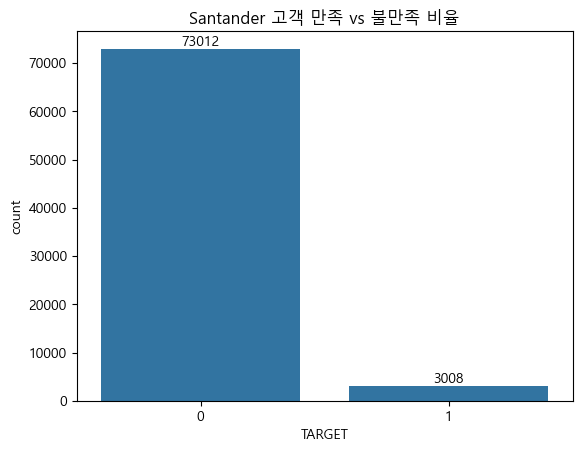

In [8]:
# 고객 만족 vs 불만족 비율 시각화 

df = pd.read_csv('../data/train.csv')

ax = sns.countplot(x="TARGET", data=df)
plt.title("Santander 고객 만족 vs 불만족 비율")

# 각 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.,  # 막대 중앙
        height,                          # 막대 높이
        f'{int(height)}',                # 표시할 수치
        ha="center", va="bottom"         # 정렬
    )

plt.show()

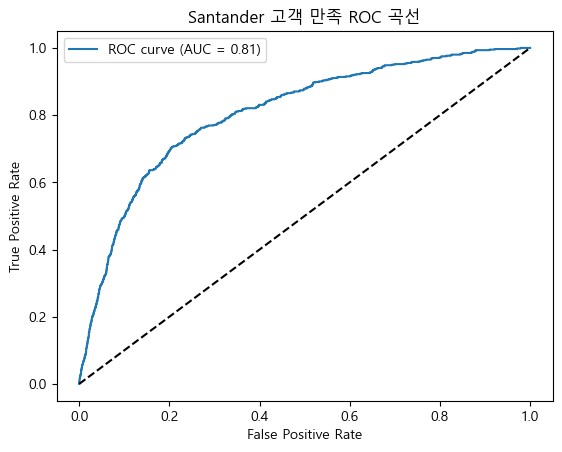

In [ ]:
# ROC 곡선

# 모델의 분류 성능 시각적으로 평가
'''
    - X축 (False Positive Rate, FPR): 실제로는 만족 고객인데 불만족으로 잘못 분류한 비율
    - Y축 (True Positive Rate, TPR): 실제 불만족 고객을 올바르게 분류한 비율
    - ROC 곡선: 모델의 임계값을 변화시키면서 FPR과 TPR을 그린 곡선
    - 대각선(랜덤 분류기): 성능이 없는 모델은 (0,0)에서 (1,1)로 이어지는 대각선에 가까움
    - AUC (Area Under Curve): ROC 곡선 아래 면적
        - 1.0에 가까울수록 → 완벽한 분류
        - 0.5에 가까울수록 → 랜덤 추측 수준
'''

X = df.drop("TARGET", axis=1)
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Santander 고객 만족 ROC 곡선")
plt.legend()
plt.show()